# Libraries

In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder,StandardScaler

import tensorflow as tf

import time

import torch
import torch.nn as nn
import torch.optim as optim

# Reading Dataset

In [2]:
filepath = '/content/drive/MyDrive/AI_&_ML/DATA/adult_dataset.csv'
adult_df = pd.read_csv(filepath)

# EDA

In [3]:
adult_df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [4]:
adult_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [5]:
adult_df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,46400.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,46400.000000
mean,38.679116,1.896641e+05,10.078089,1079.067626,87.502314,40.448599
std,13.952954,1.056040e+05,2.570973,7452.019058,403.004552,12.646992
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,255.000000,1.490400e+06,16.000000,99999.000000,4356.000000,250.000000


In [6]:
adult_df.shape

(48842, 15)

In [7]:
adult_df.isna().sum()

,0
age,2442
workclass,3362
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


In [8]:
adult_df.duplicated().sum()

np.int64(16)

In [10]:
adult_df.drop_duplicates(inplace=True)

In [12]:
num_cols = adult_df.select_dtypes(include=['int','float']).columns
num_cols

Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')

In [11]:
cat_cols = adult_df.select_dtypes(include=['object','bool']).columns
cat_cols

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object')

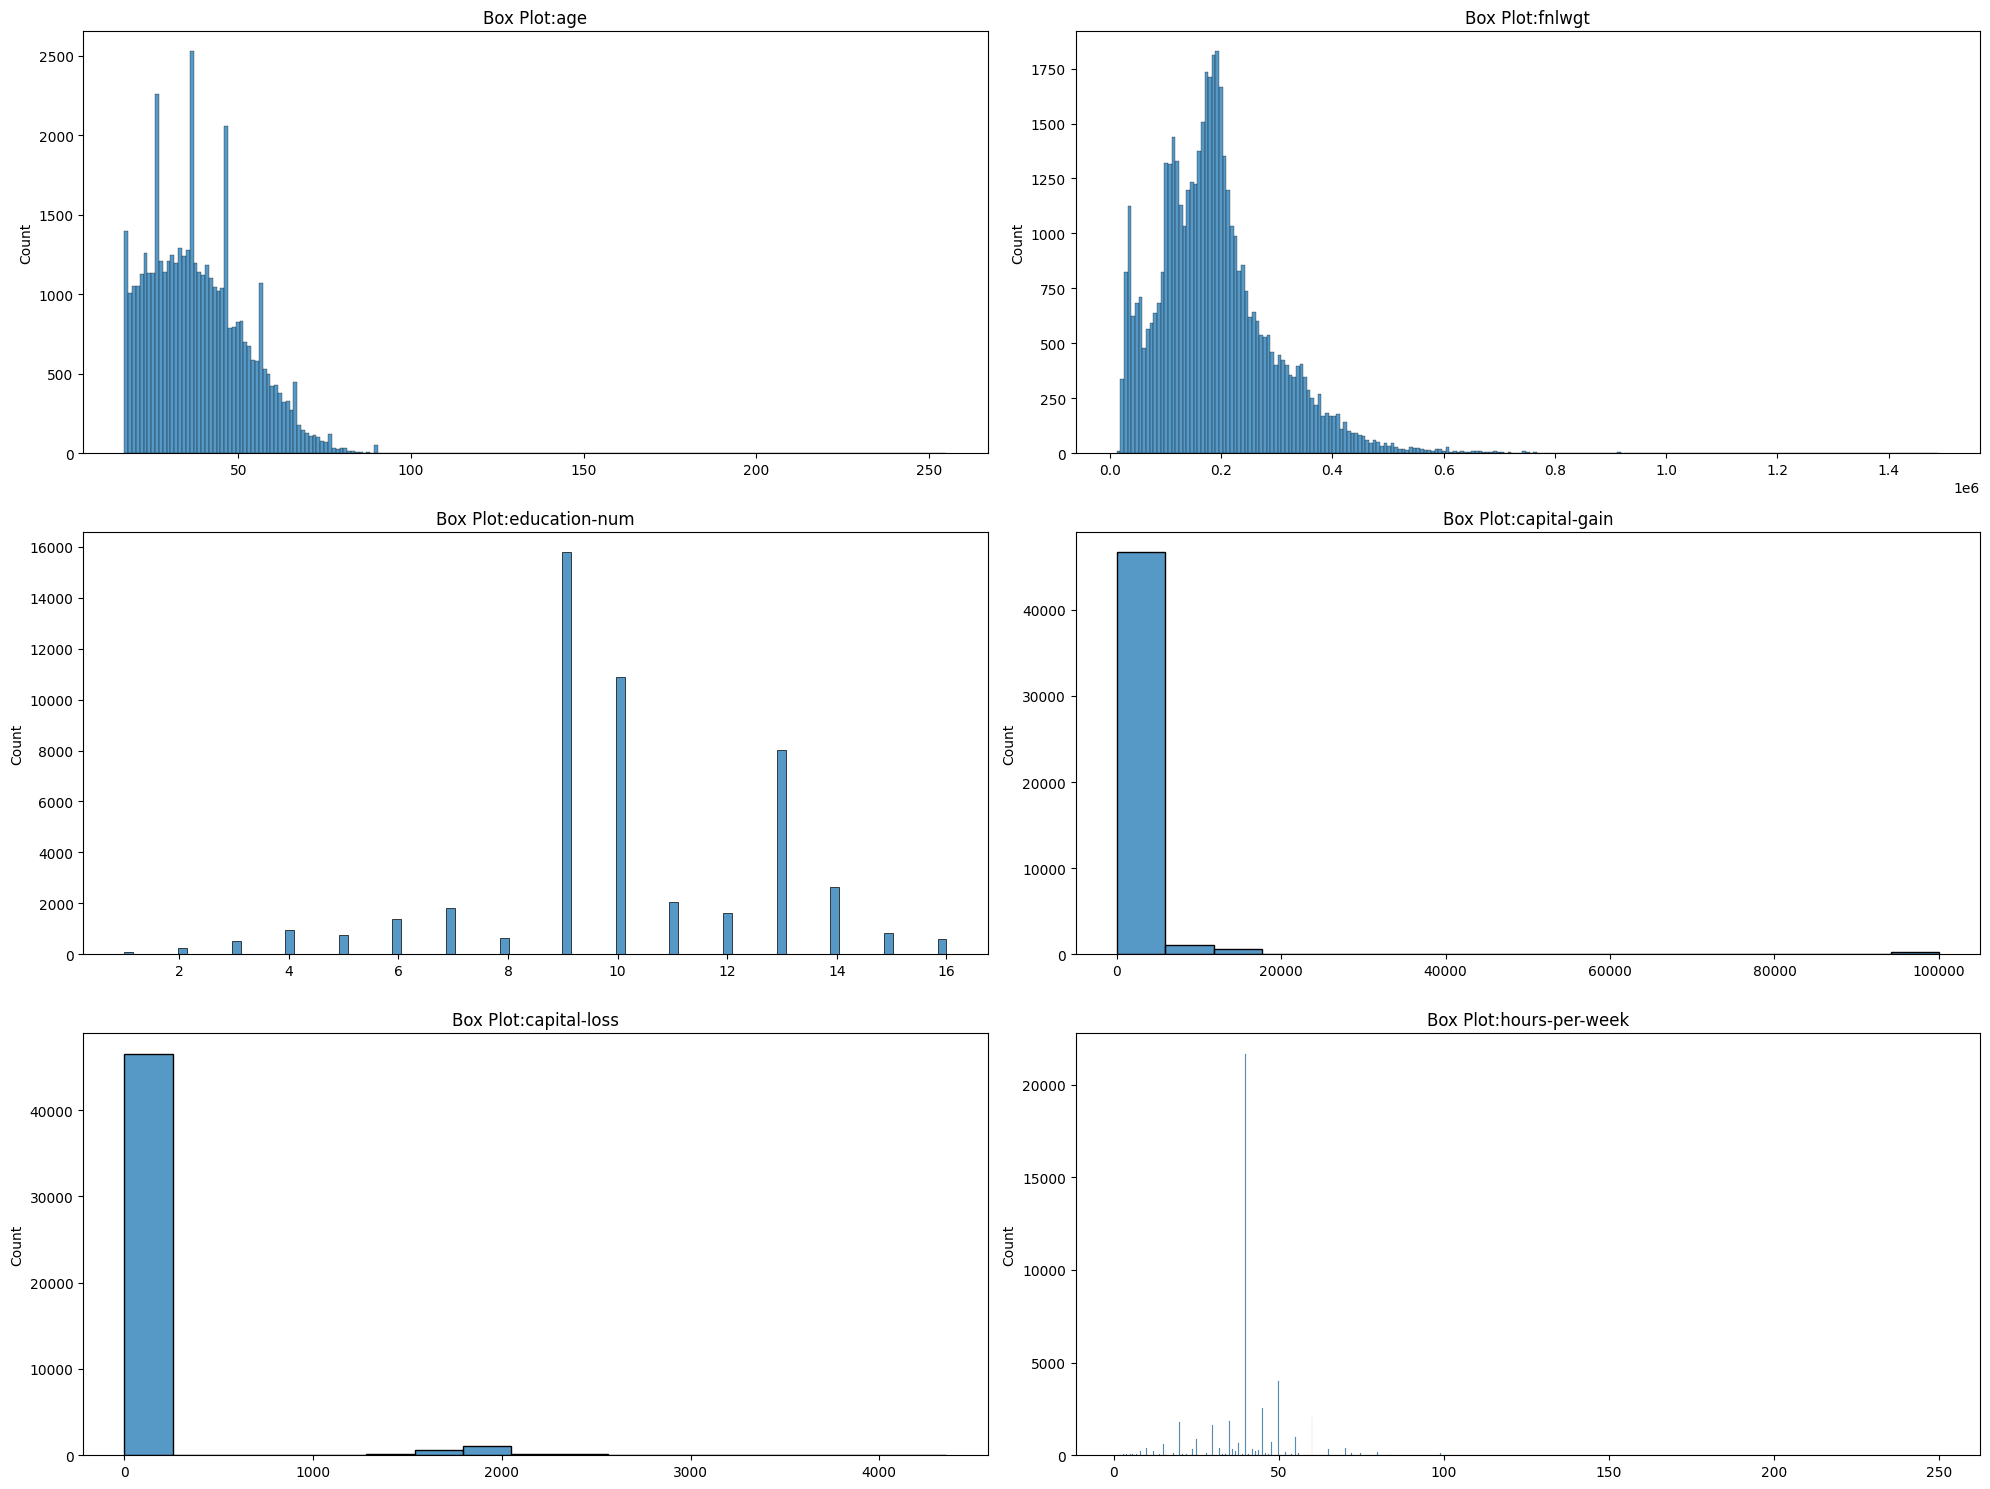

In [13]:
plt.figure(figsize=(20,15))

for i,col in enumerate(num_cols):
  plt.subplot(3,2,i+1)
  sns.histplot(adult_df[col])
  plt.title(f'Box Plot:{col}')
  plt.xlabel('')

plt.tight_layout()
plt.show()

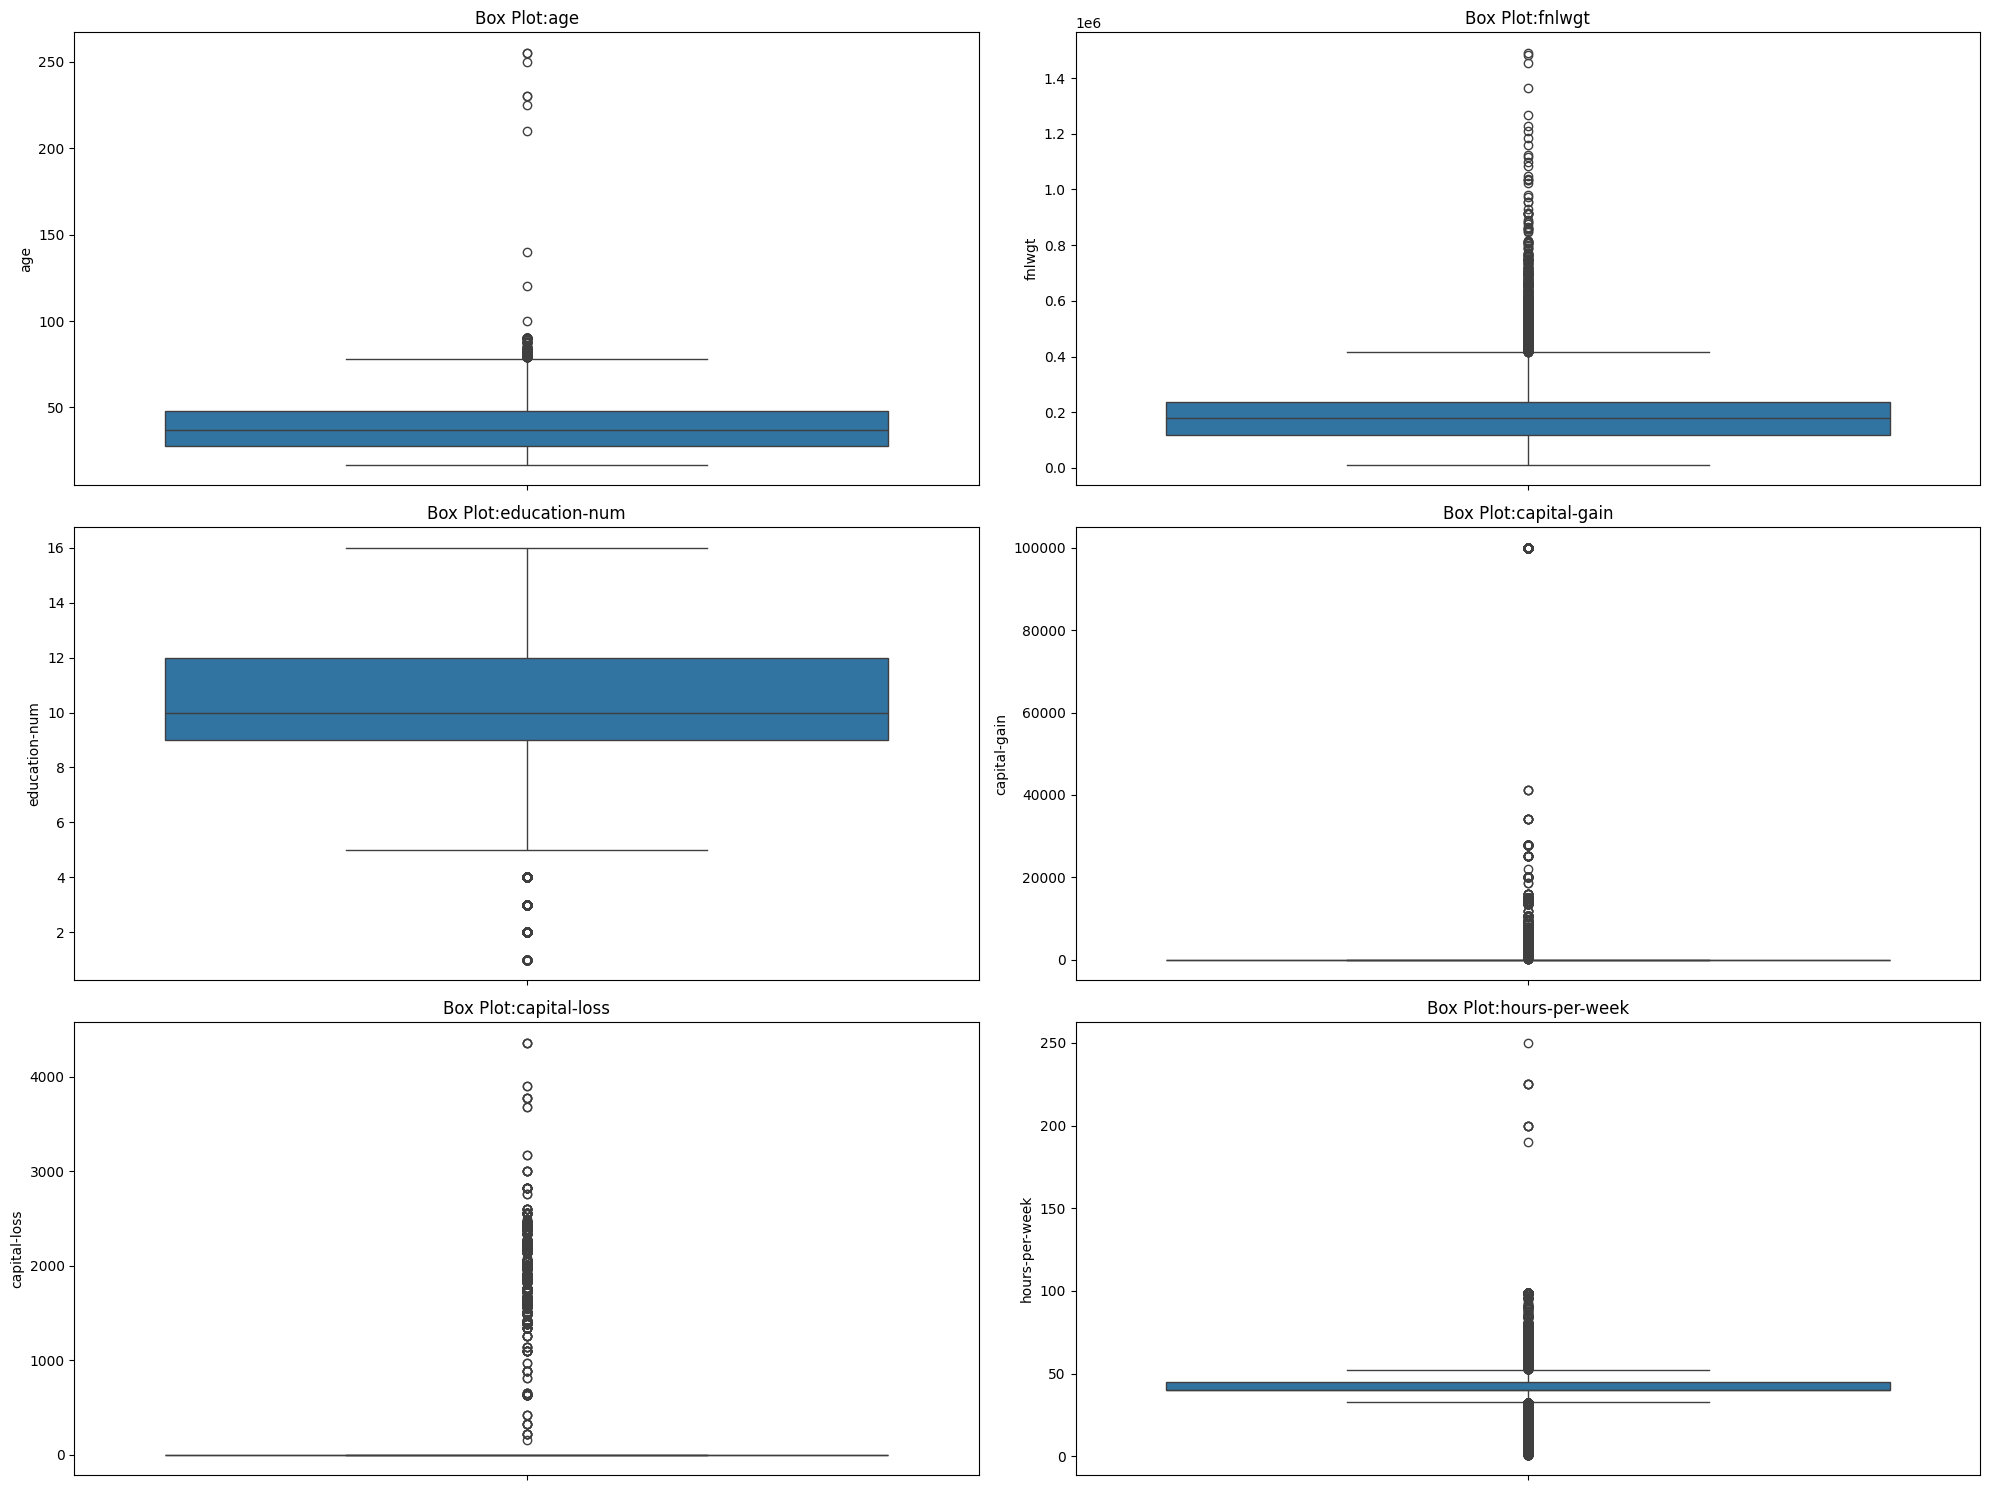

In [14]:
plt.figure(figsize=(20,15))

for i,col in enumerate(num_cols):
  plt.subplot(3,2,i+1)
  sns.boxplot(adult_df[col])
  plt.title(f'Box Plot:{col}')
  plt.xlabel('')

plt.tight_layout()
plt.show()

# Preprocessing

## Data Cleaning

### Missing value

In [15]:
adult_df.isna().sum() # before handling

,0
age,2442
workclass,3362
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


In [16]:
# Fill numerical missing values with median
adult_df['age'] = adult_df['age'].fillna(adult_df['age'].median())
adult_df['hours-per-week'] = adult_df['hours-per-week'].fillna(adult_df['hours-per-week'].median())

# Fill categorical missing values with mode
adult_df['workclass'] = adult_df['workclass'].fillna(adult_df['workclass'].mode()[0])
adult_df['occupation'] = adult_df['occupation'].fillna(adult_df['occupation'].mode()[0])
adult_df['native-country'] = adult_df['native-country'].fillna(adult_df['native-country'].mode()[0])

In [17]:
adult_df.isna().sum() # after handling

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [18]:
adult_df.drop('education', axis=1, inplace=True) # dropped because education num is also gives same info

In [19]:
adult_df.drop('race', axis=1, inplace=True) # race is not important factor

In [20]:
adult_df.drop('native-country', axis=1, inplace=True) # low importance

In [21]:
adult_df.drop('fnlwgt', axis=1, inplace=True) # census weight not important

### Outlier Handling

In [22]:
outlier_cols = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

for i in outlier_cols:
  Q1 = adult_df[i].quantile(0.25)
  Q3 = adult_df[i].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  print(f"Q1: {Q1}")
  print(f"Q3: {Q3}")
  print(f"IQR: {IQR}")
  print(f"Lower Bound: {lower_bound}")
  print(f"Upper Bound: {upper_bound}")

Q1: 28.0
Q3: 47.0
IQR: 19.0
Lower Bound: -0.5
Upper Bound: 75.5
Q1: 9.0
Q3: 12.0
IQR: 3.0
Lower Bound: 4.5
Upper Bound: 16.5
Q1: 0.0
Q3: 0.0
IQR: 0.0
Lower Bound: 0.0
Upper Bound: 0.0
Q1: 0.0
Q3: 0.0
IQR: 0.0
Lower Bound: 0.0
Upper Bound: 0.0
Q1: 40.0
Q3: 45.0
IQR: 5.0
Lower Bound: 32.5
Upper Bound: 52.5


In [23]:
# clipping

for i in outlier_cols:
  Q1 = adult_df[i].quantile(0.25)
  Q3 = adult_df[i].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  adult_df[i] = adult_df[i].clip(lower_bound, upper_bound)
  outliers = ((adult_df[i] < lower_bound) | (adult_df[i] > upper_bound))
  print(f'outliers: {outliers.sum()}')

outliers: 0
outliers: 0
outliers: 0
outliers: 0
outliers: 0


## Data Transformation

### Encoding

In [25]:
print("Unique income labels after cleaning:", adult_df['income'].unique())

le_income = LabelEncoder()
adult_df['income'] = le_income.fit_transform(adult_df['income'])
print("Encoded income classes:", adult_df['income'].unique())

le_sex = LabelEncoder()
adult_df['sex'] = le_sex.fit_transform(adult_df['sex'])


Unique income labels after cleaning: ['<=50K' '>50K' '<=50K.' '>50K.']
Encoded income classes: [0 2 1 3]


In [26]:
adult_df.head(2)

,age,workclass,education-num,marital-status,occupation,relationship,sex,capital-gain,capital-loss,hours-per-week,income
0,39.0,State-gov,13.0,Never-married,Adm-clerical,Not-in-family,1,0,0,40.0,0
1,50.0,Self-emp-not-inc,13.0,Married-civ-spouse,Exec-managerial,Husband,1,0,0,32.5,0


In [27]:
one_hot_columns = [
    'workclass',
    'marital-status',
    'occupation',
    'relationship'
]

adult_df = pd.get_dummies(
    adult_df,
    columns=one_hot_columns,
    drop_first=True,
    dtype=int
)

In [28]:
adult_df.head(2)

,age,education-num,sex,capital-gain,capital-loss,hours-per-week,income,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,...,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife
0,39.0,13.0,1,0,0,40.0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,50.0,13.0,1,0,0,32.5,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [29]:
adult_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48826 entries, 0 to 48841
Data columns (total 40 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   48826 non-null  float64
 1   education-num                         48826 non-null  float64
 2   sex                                   48826 non-null  int64  
 3   capital-gain                          48826 non-null  int64  
 4   capital-loss                          48826 non-null  int64  
 5   hours-per-week                        48826 non-null  float64
 6   income                                48826 non-null  int64  
 7   workclass_Federal-gov                 48826 non-null  int64  
 8   workclass_Local-gov                   48826 non-null  int64  
 9   workclass_Never-worked                48826 non-null  int64  
 10  workclass_Private                     48826 non-null  int64  
 11  workclass_Self-emp-i

### Train test split

In [30]:
X = adult_df.drop('income', axis=1)
y = adult_df['income']

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (48826, 39)
y shape: (48826,)


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (39060, 39)
X_test: (9766, 39)
y_train: (39060,)
y_test: (9766,)


### Scaling

In [32]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Tensorflow



In [34]:
model_tf = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation = 'relu', input_shape=(39,)),
    tf.keras.layers.Dense(32, activation = 'relu'),
    tf.keras.layers.Dense(1, activation = 'sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
model_tf.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [44]:
start_time = time.perf_counter()
history = model_tf.fit(X_train,
    y_train,
    epochs = 50,
    batch_size = 32,
    validation_split = 0.2,
    verbose = 0
)
end_time = time.perf_counter()
print(f"Training time : {end_time - start_time:.4f} seconds")

Training time : 87.5198 seconds


In [37]:
loss, accuracy = model_tf.evaluate(X_test, y_test)

print("Accuracy:", accuracy)

306/306 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2867 - loss: -61694340.0000
Accuracy: 0.2867089807987213


In [38]:
print("Accuracy : ",accuracy)

Accuracy :  0.2867089807987213


# Pytorch

In [39]:
# convert every data into tensor
X_train_tensor = torch.FloatTensor(X_train)

X_test_tensor = torch.FloatTensor(X_test)

y_train_tensor = torch.FloatTensor(y_train.values.reshape(-1,1))

y_test_tensor = torch.FloatTensor(y_test.values.reshape(-1,1))

In [40]:
class ANN(nn.Module) :
  def __init__ (self):
    super().__init__()
    self.network = nn.Sequential(
      nn.Linear (39,64),
      nn.ReLU(),
      nn.Linear(64,32),
      nn.ReLU(),
      nn.Linear(32,1),
      nn.Sigmoid()
    )
  def forward(self,x):
    return self.network(x)

In [41]:
model_pt = ANN()

In [42]:
criterion = nn.BCELoss()      # Binary crossentropy

In [43]:
optimizer = optim.Adam(
    model_pt.parameters(),
    lr=0.001
)

In [ ]:
start_time = time.perf_counter()

# Remap the target tensor to binary (0 or 1) for BCELoss
# Assuming that LabelEncoder values 0 and 2 correspond to one class (e.g., '<=50K')
# and values 1 and 3 correspond to the other class (e.g., '>50K').
# So, we convert values 1 or 3 to 1.0 and others (0 or 2) to 0.0.
y_train_tensor = ((y_train_tensor == 1) | (y_train_tensor == 3)).float()

epochs = 50
for epoch in range(epochs):
   outputs = model_pt(X_train_tensor)
   loss = criterion(outputs,y_train_tensor)
   optimizer.zero_grad()
   loss.backward()
   optimizer.step()
   if(epoch+1)%10 ==0:
    print(f"Epoch{epoch+1}",f"Loss={loss.item():.4f}")
end_time = time.perf_counter()

print(f"Training time  : {end_time - start_time:.4f} seconds")

Epoch10 Loss=0.6600
Epoch20 Loss=0.6429
Epoch30 Loss=0.6400
Epoch40 Loss=0.6367
Epoch50 Loss=0.6346
Training time  : 2.2582 seconds
